# LS-DYNA d3plot and Nastran OP2 results

Added in v16.9.0, two solver result files, read-only:

- **LS-DYNA `d3plot`** is the binary state database LS-DYNA writes for post-processing, and what most public crash datasets and physics-ML pipelines start from: the geometry, then one state per output time, split across `d3plot`, `d3plot01`, `d3plot02`... Every state is a step, parts are regions, integration-point variables use the `(cells, points × components)` layout, and the deletion flags are the mask `lsdyna:alive`.
- **Nastran OP2** is the binary result file MSC and Simcenter (NX) Nastran write with `PARAM,POST,-1`. The mesh is built as for MSC's HDF5 results; every subcase, mode or time is a step, with displacements, eigenvectors, forces and the stress and strain of rods, bars, shells and solids.

The d3plot families are in `tests/python/meshes/lsdyna_d3plot/`: real LS-DYNA output from lasso-python's test data (BSD-3) and families written with lasso-python. The OP2 files are MSC and NX output from pyNastran's test models (BSD-3).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def von_mises(t):
    """The von Mises stress of tensors ``xx yy zz xy yz zx`` (the last axis)."""
    xx, yy, zz, xy, yz, zx = np.moveaxis(t, -1, 0)
    return np.sqrt(0.5 * ((xx - yy) ** 2 + (yy - zz) ** 2 + (zz - xx) ** 2) + 3 * (xy**2 + yz**2 + zx**2))

## A d3plot family, state by state

`generated/shell_solid` is a small crash-like model: a hexahedron, a wedge and a tetrahedron (LS-DYNA writes all three as 8-node solids with repeated nodes; they are collapsed on read), a plate of shells above them and two beams. Over four states the plate bends, plastic strain grows and elements are deleted. The file is found by its name, `d3plot`, which has no extension.

In [2]:
d3 = path('lsdyna_d3plot/generated/shell_solid', 'd3plot')
print('states at t =', mp.lsdyna_d3plot.time_values(d3))
last = mp.read(d3, time_step=-1)
print(last)
for r in last.regions:
    print(f'part {r.tag}: {r.name!r} ({r.dim}D, {len(r.entries)} cells)')
layout = last.field_data['lsdyna_d3plot:layout:stress']
print('stress', last.cell_data['stress'][4].shape, '-> [points, components] =', layout.tolist())

states at t = [0.0, 0.0010000000474974513, 0.0020000000949949026, 0.003000000026077032]
<meshio++ mesh object>
  Number of points: 24
  Number of cells:
    hexahedron: 1
    wedge: 1
    tetra: 1
    line: 2
    quad: 5
    triangle: 1
  Cell sets: block, plate, struts
  Point data: displacement, lsdyna:nid, velocity
  Cell data: beam_axial_force, beam_bending_moment, beam_shear_force, beam_torsion_moment, effective_plastic_strain, internal_energy, lsdyna:alive, lsdyna:eid, lsdyna:part, shell_element_variables, stress, thickness
  Field data: global_internal_energy, global_kinetic_energy, global_total_energy, global_velocity, lsdyna:state, lsdyna_d3plot:layout:effective_plastic_strain, lsdyna_d3plot:layout:stress, meshio:time
part 100: 'block' (3D, 3 cells)
part 200: 'plate' (2D, 6 cells)
part 300: 'struts' (1D, 2 cells)
stress (5, 18) -> [points, components] = [3, 6]


Deleted cells stay in the mesh, so every state has the same cells; `lsdyna:alive` says which are gone (1 active, 0 deleted). Here each state is drawn with its deleted cells removed, coloured by the plastic strain averaged over the integration points or layers and warped by the displacement.

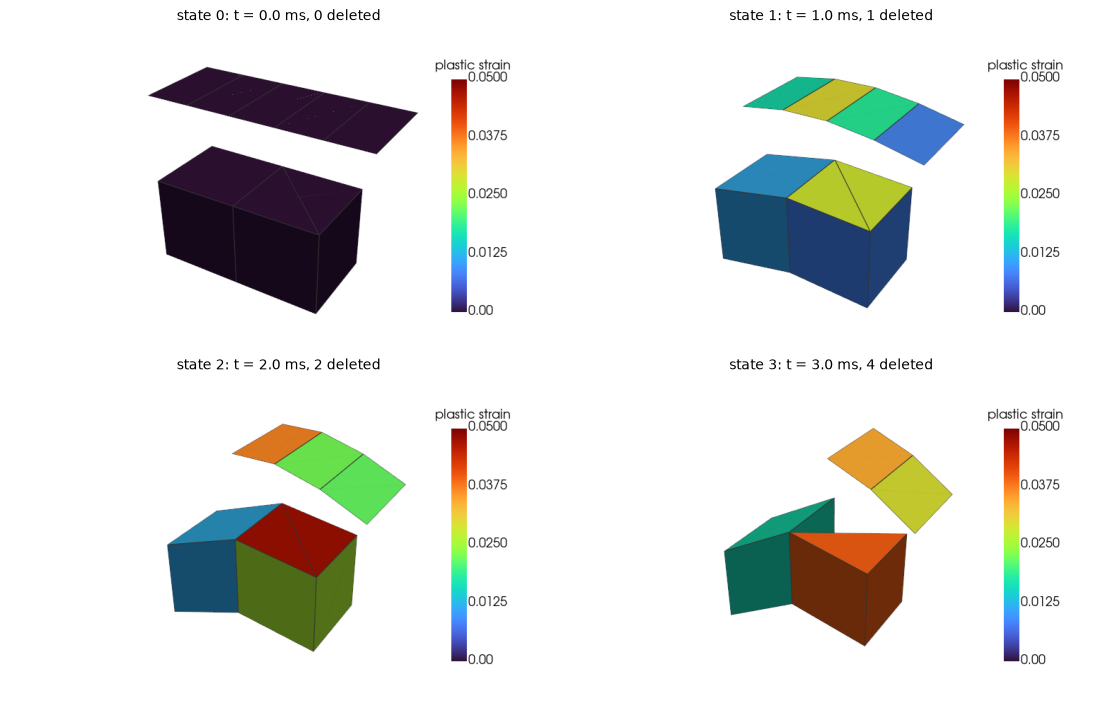

In [3]:
items = []
for step, (time, state) in enumerate(mp.read_sequence(d3)):
    alive = state.cell_data['lsdyna:alive']
    # the mean over each cell's integration points or layers (beams have none: NaN)
    eps = [np.nanmean(np.where(np.isnan(a), np.nan, a).reshape(len(a), -1), axis=1)
           if np.isfinite(a).any() else np.full(len(a), np.nan)
           for a in state.cell_data['effective_plastic_strain']]
    keep = [(i, np.flatnonzero(al)) for i, al in enumerate(alive)]
    cells = [mp.CellBlock(state.cells[i].type, state.cells[i].data[k]) for i, k in keep if len(k)]
    data = [eps[i][k] for i, k in keep if len(k)]
    live = mp.Mesh(state.points, cells)
    grid = to_grid(live, point_data={'displacement': state.point_data['displacement']},
                   cell_data={'plastic strain': data})
    deleted = sum(int((a == 0).sum()) for a in alive)
    items.append((grid.warp_by_vector('displacement', factor=4.0), 'plastic strain',
                  f'state {step}: t = {time * 1e3:.1f} ms, {deleted} deleted', (0.0, 0.05)))
gallery(items, ncols=2, view=(0.6, -1.0, 0.7))

## Real LS-DYNA output

`lasso/simple_d3plot` is a plate of 4696 shells from a real LS-DYNA run, with three layers of stress and 19 history variables per layer, its one state (t = 0, the initial conditions) in `d3plot01`. At t = 0 the stresses are still zero; the initial velocity is not.

['effective_plastic_strain', 'history_variables', 'internal_energy', 'lsdyna:alive', 'lsdyna:eid', 'lsdyna:part', 'shell_bending_moment', 'shell_element_variables', 'shell_normal_force', 'shell_shear_force', 'strain_inner', 'strain_outer', 'stress', 'thickness']
stress per layer: (4696, 3, 6) | max |stress| at t = 0: 0.0


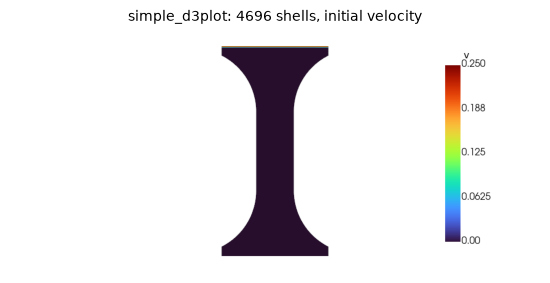

In [4]:
plate = mp.read(path('lsdyna_d3plot/lasso/simple_d3plot', 'd3plot'))
print(sorted(plate.cell_data))
layers = plate.cell_data['stress'][0].reshape(-1, *plate.field_data['lsdyna_d3plot:layout:stress'])
print('stress per layer:', layers.shape, '| max |stress| at t = 0:', np.abs(layers).max())
grid = to_grid(plate, point_data={'|v|': np.linalg.norm(plate.point_data['velocity'], axis=1)})
gallery([(grid, '|v|', 'simple_d3plot: 4696 shells, initial velocity', None)], ncols=1, size=(1000, 460),
        view=(0.0, -1.0, 0.0), edges=False)

`lasso/d3plot_solid_int` holds 16 solids with 8 integration points and 16 shells with 5 layers over 22 states, one per file. `read_sequence` walks them; the global energies are field data.

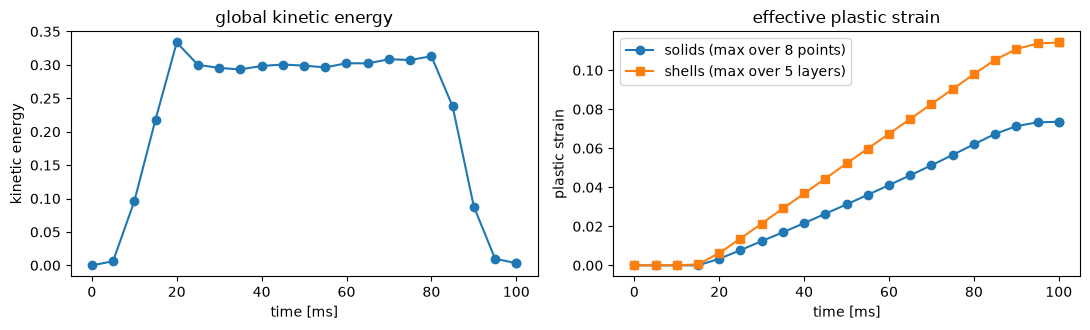

In [5]:
family = path('lsdyna_d3plot/lasso/d3plot_solid_int', 'd3plot')
times, ke, eps_solid, eps_shell = [], [], [], []
for time, state in mp.read_sequence(family):
    times.append(time * 1e3)
    ke.append(state.field_data['global_kinetic_energy'][0])
    blocks = {c.type: i for i, c in enumerate(state.cells)}
    eps = state.cell_data['effective_plastic_strain']
    eps_solid.append(np.nanmax(eps[blocks['hexahedron']]))
    eps_shell.append(np.nanmax(eps[blocks['quad']]))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(times, ke, 'o-')
a1.set(xlabel='time [ms]', ylabel='kinetic energy', title='global kinetic energy')
a2.plot(times, eps_solid, 'o-', label='solids (max over 8 points)')
a2.plot(times, eps_shell, 's-', label='shells (max over 5 layers)')
a2.set(xlabel='time [ms]', ylabel='plastic strain', title='effective plastic strain')
a2.legend()
plt.tight_layout()
plt.show()

## A Nastran OP2: SOL 101

`static_solid_shell_bar.op2` (NX Nastran 8.5) is a static model of solids, shells, bars and rods. The mesh comes from the file's own geometry tables, with one region per property; the results carry the names of MSC's HDF5 schema (`STRESS:X`, `STRESS:X1`...) plus the derived values the OP2 stores (`VON_MISES`, `VON_MISES1` for the first fibre of a shell).

<meshio++ mesh object>
  Number of points: 25
  Number of cells:
    line: 1
    line: 1
    hexahedron: 1
    wedge: 2
    quad: 4
    line: 2
    tetra: 2
    triangle: 8
  Cell sets: PBAR_1, PBEAM_5, PCOMP_6, PCOMP_7, PROD_3, PSHELL_4, PSOLID_2
  Point data: APPLIED_LOAD, APPLIED_LOAD_ROT, DISPLACEMENT, DISPLACEMENT_ROT, MPC_FORCE, MPC_FORCE_ROT, SPC_FORCE, SPC_FORCE_ROT
  Cell data: STRAIN:A, STRAIN:ANGLE1, STRAIN:ANGLE2, STRAIN:AX, STRAIN:FD1, STRAIN:FD2, STRAIN:MAJOR1, STRAIN:MAJOR2, STRAIN:MAXA, STRAIN:MAXB, STRAIN:MINA, STRAIN:MINB, STRAIN:MINOR1, STRAIN:MINOR2, STRAIN:MSA, STRAIN:MSC, STRAIN:MST, STRAIN:PRESSURE, STRAIN:PRINCIPAL_A, STRAIN:PRINCIPAL_B, STRAIN:PRINCIPAL_C, STRAIN:T, STRAIN:TXY, STRAIN:TXY1, STRAIN:TXY2, STRAIN:TYZ, STRAIN:TZX, STRAIN:VON_MISES, STRAIN:VON_MISES1, STRAIN:VON_MISES2, STRAIN:X, STRAIN:X1, STRAIN:X1A, STRAIN:X1B, STRAIN:X2, STRAIN:X2A, STRAIN:X2B, STRAIN:X3A, STRAIN:X3B, STRAIN:X4A, STRAIN:X4B, STRAIN:Y, STRAIN:Y1, STRAIN:Y2, STRAIN:Z, STRESS:A, ST

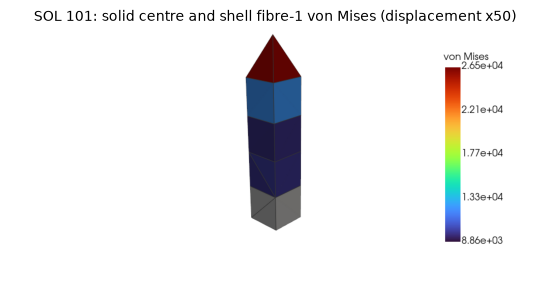

In [6]:
op2 = path('nastran_op2', 'static_solid_shell_bar.op2')
static = mp.read(op2)
print(static)
print('regions:', [r.name for r in static.regions])
print('point data:', sorted(static.point_data))
vm = [np.where(np.isnan(s), sh, s) for s, sh in zip(static.cell_data['STRESS:VON_MISES'], static.cell_data['STRESS:VON_MISES1'])]
grid = to_grid(static, point_data={'U': static.point_data['DISPLACEMENT']}, cell_data={'von Mises': vm})
gallery([(grid.warp_by_vector('U', factor=50.0), 'von Mises',
          'SOL 101: solid centre and shell fibre-1 von Mises (displacement x50)', None)], ncols=1,
        size=(1000, 460), view=(1.0, -1.0, 0.6))

## Modes

`mode_solid_shell_bar.op2` (MSC Nastran) is the same model's first three modes. Each mode is a step: `meshio:time` is its eigenvalue λ = ω², as written, and `nastran:mode` its number.

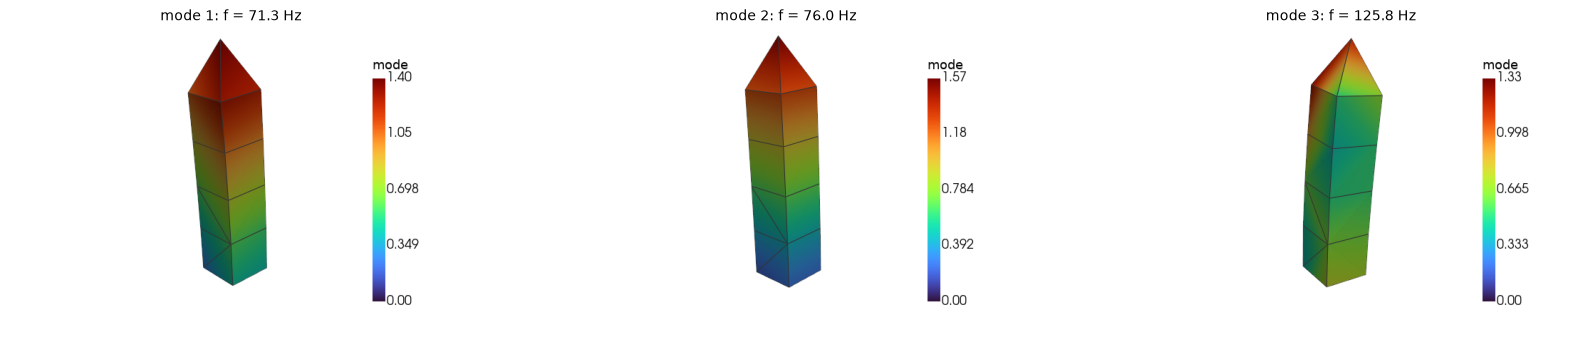

In [7]:
modes = path('nastran_op2', 'mode_solid_shell_bar.op2')
items = []
for time, step in mp.read_sequence(modes):
    mode = int(step.field_data['nastran:mode'][0])
    shape = step.point_data['EIGENVECTOR']
    grid = to_grid(step, point_data={'mode shape': shape, '|mode|': np.linalg.norm(shape, axis=1)})
    items.append((grid.warp_by_vector('mode shape', factor=0.3), '|mode|',
                  f'mode {mode}: f = {np.sqrt(time) / (2 * np.pi):.1f} Hz', None))
gallery(items, ncols=3, size=(620, 440), view=(1.0, -1.0, 0.6))

## An OP2 without its geometry

Many OP2 files carry results only. `solid_bending_no_geom.op2` is `solid_bending.op2` with its geometry tables removed; the reader takes the mesh from the input deck beside it, `solid_bending_no_geom.bdf`, and the results match the full file's element by element.

72 points, 186 cells from the deck
same von Mises per element as the full file: True


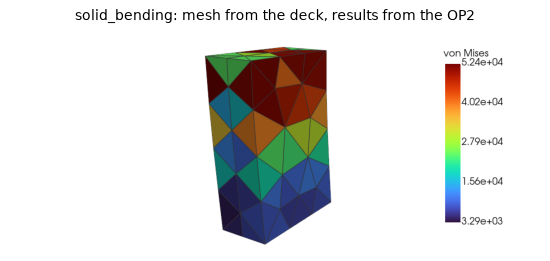

In [8]:
bare = mp.read(path('nastran_op2', 'solid_bending_no_geom.op2'))
full = mp.read(path('nastran_op2', 'solid_bending.op2'))
by_id = lambda m: dict(zip(np.concatenate(m.cell_data['nastran:eid']).tolist(),
                           np.concatenate(m.cell_data['STRESS:VON_MISES']).tolist()))
print(len(bare.points), 'points,', sum(len(c.data) for c in bare.cells), 'cells from the deck')
print('same von Mises per element as the full file:', by_id(bare) == by_id(full))
grid = to_grid(bare, point_data={'U': bare.point_data['DISPLACEMENT']},
               cell_data={'von Mises': bare.cell_data['STRESS:VON_MISES']})
gallery([(grid.warp_by_vector('U', factor=20.0), 'von Mises', 'solid_bending: mesh from the deck, results from the OP2', None)],
        ncols=1, size=(1000, 420), view=(1.0, -1.2, 0.5))